# **Quantifying Finfluencer Influence on Gen Z Investment Decisions using Multiple Linear Regression**


**Muhammad Haris Khan**

**Department of Accounting and Finance**

**FAST National University of Computing and Emerging Sciences**

**Islamabad, Pakistan**


Basic Checks & Data Cleaning

In [35]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Load the Dataset
df = pd.read_csv("dataset_BRDM.csv", encoding='latin1')
display(df.head(10))

,Active_Status,IE,SME1,SME2,ICT1,HB1,OC1,ICT2,FOMO,OC2,ICT3,HB2,OC3,AIB1,AIB2,AIB3,AIB4,FL1,FL2,FL3
0,Yes,1 to 3 years,15+ hours,"X (Twitter), YouTube, Financial News Websites ...",3 - Neutral,5 - Strongly Agree,4 - Agree,1 - Strongly Disagree,5 - Strongly Agree,4 - Agree,5 - Strongly Agree,4 - Agree,5 - Strongly Agree,2 - Disagree,3 - Neutral,4 - Agree,2 - Disagree,Less than today,FALSE,High risk
1,Yes,6 months to 1 year,814 hours,"YouTube, Reddit (e.g., r/wallstreetbets)",1 - Strongly Disagree,1 - Strongly Disagree,4 - Agree,1 - Strongly Disagree,4 - Agree,1 - Strongly Disagree,4 - Agree,4 - Agree,4 - Agree,4 - Agree,1 - Strongly Disagree,2 - Disagree,2 - Disagree,Less than today,FALSE,High risk
2,Yes,Less than 6 months,13 hours,"YouTube, Instagram / TikTok, Financial News We...",3 - Neutral,2 - Disagree,4 - Agree,3 - Neutral,3 - Neutral,4 - Agree,3 - Neutral,2 - Disagree,3 - Neutral,3 - Neutral,3 - Neutral,3 - Neutral,3 - Neutral,Less than today,FALSE,Low risk
3,Yes,NaN,13 hours,"X (Twitter), YouTube, Instagram / TikTok",2 - Disagree,1 - Strongly Disagree,4 - Agree,2 - Disagree,4 - Agree,1 - Strongly Disagree,2 - Disagree,2 - Disagree,4 - Agree,2 - Disagree,3 - Neutral,1 - Strongly Disagree,1 - Strongly Disagree,Less than today,NaN,NaN
4,Yes,3 to 5 years,13 hours,"X (Twitter), Instagram / TikTok",3 - Neutral,3 - Neutral,2 - Disagree,2 - Disagree,3 - Neutral,3 - Neutral,1 - Strongly Disagree,3 - Neutral,3 - Neutral,1 - Strongly Disagree,3 - Neutral,1 - Strongly Disagree,1 - Strongly Disagree,Less than today,FALSE,High risk
5,Yes,6 months to 1 year,47 hours,"X (Twitter), Instagram / TikTok, Financial New...",3 - Neutral,2 - Disagree,2 - Disagree,3 - Neutral,3 - Neutral,3 - Neutral,2 - Disagree,4 - Agree,5 - Strongly Agree,4 - Agree,2 - Disagree,1 - Strongly Disagree,4 - Agree,Less than today,FALSE,High risk
6,No,Less than 6 months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,No,Less than 6 months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,No,Less than 6 months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,No,Less than 6 months,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***Data Preprocessing (Mapping, Imputation & Feature Engineering)***

In [36]:
# ==========================================
# GROUP 2: Basic Filtering & Checks
# ==========================================
# Drop rows where the user is not an active trader
column_name = 'Active_Status'
df = df[df[column_name] != 'No']
print("The dataset after removing Non Active Traders")
print(df.columns)

# Remove Active_Status column as it is no longer needed
df.drop(columns=['Active_Status'], inplace=True)
print("\n\nThe dataset after removing active_status")
print(df.columns)

The dataset after removing Non Active Traders
Index(['Active_Status', 'IE', 'SME1', 'SME2', 'ICT1', 'HB1', 'OC1', 'ICT2',
       'FOMO', 'OC2', 'ICT3', 'HB2', 'OC3', 'AIB1', 'AIB2', 'AIB3', 'AIB4',
       'FL1', 'FL2', 'FL3'],
      dtype='object')


The dataset after removing active_status
Index(['IE', 'SME1', 'SME2', 'ICT1', 'HB1', 'OC1', 'ICT2', 'FOMO', 'OC2',
       'ICT3', 'HB2', 'OC3', 'AIB1', 'AIB2', 'AIB3', 'AIB4', 'FL1', 'FL2',
       'FL3'],
      dtype='object')


In [37]:
# ==========================================
# GROUP 3: Variable Mapping (Likert, SME, IE, FL)
# ==========================================
# --- Map Likert Scales ---
def map_likert(val):
    if pd.isna(val): return np.nan
    mapping = {
        '1 - Strongly Disagree': 1, 'Strongly Disagree': 1,
        '2 - Disagree': 2, 'Disagree': 2,
        '3 - Neutral': 3, 'Neutral': 3,
        '4 - Agree': 4, 'Agree': 4,
        '5 - Strongly Agree': 5, 'Strongly Agree': 5
    }
    for k, v in mapping.items():
        if k in str(val): return v
    return np.nan

ict_cols = ['ICT1', 'ICT2', 'ICT3']
hb_cols = ['HB1', 'FOMO', 'HB2']
oc_cols = ['OC1', 'OC2', 'OC3']
aib_cols = ['AIB1', 'AIB2', 'AIB3', 'AIB4']
likert_columns_to_map = ict_cols + hb_cols + oc_cols + aib_cols

for col in likert_columns_to_map:
    df[col] = df[col].apply(map_likert)

# --- Map Social Media Engagement (SME) ---
sme1_map = {
    'Less than 1 hour': 1,
    '1–3 hours': 2,
    '4–7 hours': 3,
    '8–14 hours': 4,
    '15+ hours': 5
}
df['SME1_mapped'] = df['SME1'].map(sme1_map)

def count_platforms(val):
    if pd.isna(val): return np.nan
    platforms = str(val).split(',')
    return len(platforms)

df['SME2_mapped'] = df['SME2'].apply(count_platforms)

df.drop(columns=['SME1', 'SME2'], inplace=True)
df.rename(columns={'SME1_mapped': 'SME1', 'SME2_mapped': 'SME2'}, inplace=True)

# --- Map Investment Experience (IE) ---
ie_map = {
    'Less than 6 months': 1,
    '6 months to 1 year': 2,
    '1 to 3 years': 3,
    '3 to 5 years': 4,
    'More than 5 years': 5
}
df['IE_mapped'] = df['IE'].map(ie_map)
df.drop(columns=['IE'], inplace=True)
df.rename(columns={'IE_mapped': 'IE'}, inplace=True)

# --- Map Financial Literacy (FL) ---
df['FL1_mapped'] = df['FL1'].apply(lambda x: 1.0 if str(x).strip() == 'Less than today' else (np.nan if pd.isna(x) else 0.0))
df['FL2_mapped'] = df['FL2'].apply(lambda x: 1.0 if str(x).strip() == 'False' else (np.nan if pd.isna(x) else 0.0))
df['FL3_mapped'] = df['FL3'].apply(lambda x: 1.0 if str(x).strip() == 'High risk' else (np.nan if pd.isna(x) else 0.0))

df.drop(columns=['FL1', 'FL2', 'FL3'], inplace=True)
df.rename(columns={'FL1_mapped': 'FL1', 'FL2_mapped': 'FL2', 'FL3_mapped': 'FL3'}, inplace=True)

print("\n\nAfter Mapping")
print(df.head(5))



After Mapping
   ICT1  HB1  OC1  ICT2  FOMO  OC2  ICT3  HB2  OC3  AIB1  AIB2  AIB3  AIB4  \
0     3    4    4     1     4    4     4    4    4     2     3     4     2   
1     1    1    4     1     4    1     4    4    4     4     1     2     2   
2     3    2    4     3     3    4     3    2    3     3     3     3     3   
3     2    1    4     2     4    1     2    2    4     2     3     1     1   
4     3    3    2     2     3    3     1    3    3     1     3     1     1   

   SME1  SME2   IE  FL1  FL2  FL3  
0   5.0     4  3.0  1.0  0.0  1.0  
1   NaN     3  2.0  1.0  0.0  1.0  
2   NaN     4  1.0  1.0  0.0  0.0  
3   NaN     3  NaN  1.0  NaN  NaN  
4   NaN     2  4.0  1.0  0.0  1.0  


In [38]:
# ==========================================
# GROUP 4: Missing Data Imputation
# ==========================================
# Columns to impute: SME1, IE, FL2, FL3 using the Mode
for col in ['SME1', 'IE', 'FL2', 'FL3']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("\n\nAfter Imputation")
print(df.isna().sum())



After Imputation
ICT1    0
HB1     0
OC1     0
ICT2    0
FOMO    0
OC2     0
ICT3    0
HB2     0
OC3     0
AIB1    0
AIB2    0
AIB3    0
AIB4    0
SME1    0
SME2    0
IE      0
FL1     0
FL2     0
FL3     0
dtype: int64


In [39]:
# ==========================================
# GROUP 5: Feature Engineering & Final Dataset
# ==========================================
# Create composite mean scores
df['ICT_comp'] = df[['ICT1', 'ICT2', 'ICT3']].mean(axis=1)
df['HB_comp']  = df[['HB1', 'FOMO', 'HB2']].mean(axis=1)
df['OC_comp']  = df[['OC1', 'OC2', 'OC3']].mean(axis=1)
df['SME_comp'] = df[['SME1', 'SME2']].mean(axis=1)
df['AIB_comp'] = df[['AIB1', 'AIB2', 'AIB3', 'AIB4']].mean(axis=1)

# Create total score for Financial Literacy
df['FL_score'] = df['FL1'] + df['FL2'] + df['FL3']

# Isolate final features and rename them
needed_columns = ['SME_comp', 'ICT_comp', 'HB_comp', 'OC_comp', 'FL_score', 'IE', 'AIB_comp']
final_analysis_df = df[needed_columns].copy()

rename_dict = {
    'SME_comp': 'SME',
    'ICT_comp': 'ICT',
    'HB_comp': 'HB',
    'OC_comp': 'OC',
    'FL_score': 'FL',
    'AIB_comp': 'AIB'
}
final_analysis_df = final_analysis_df.rename(columns=rename_dict)
df = final_analysis_df.copy()

print("\n\n Final Dataset")
print(df.head(5))




 Final Dataset
   SME       ICT        HB        OC   FL   IE   AIB
0  4.5  2.666667  4.000000  4.000000  2.0  3.0  2.75
1  4.0  2.000000  3.000000  3.000000  2.0  2.0  2.25
2  4.5  3.000000  2.333333  3.666667  1.0  1.0  3.00
3  4.0  2.000000  2.333333  3.000000  2.0  3.0  1.75
4  3.5  2.000000  3.000000  2.666667  2.0  4.0  1.50


In [40]:
# # Export the current dataframe to an excel file and download it
# file_name = "Final_dataset_BRDM.xlsx"
# df.to_excel(file_name, index=False)

# from google.colab import files
# files.download(file_name)

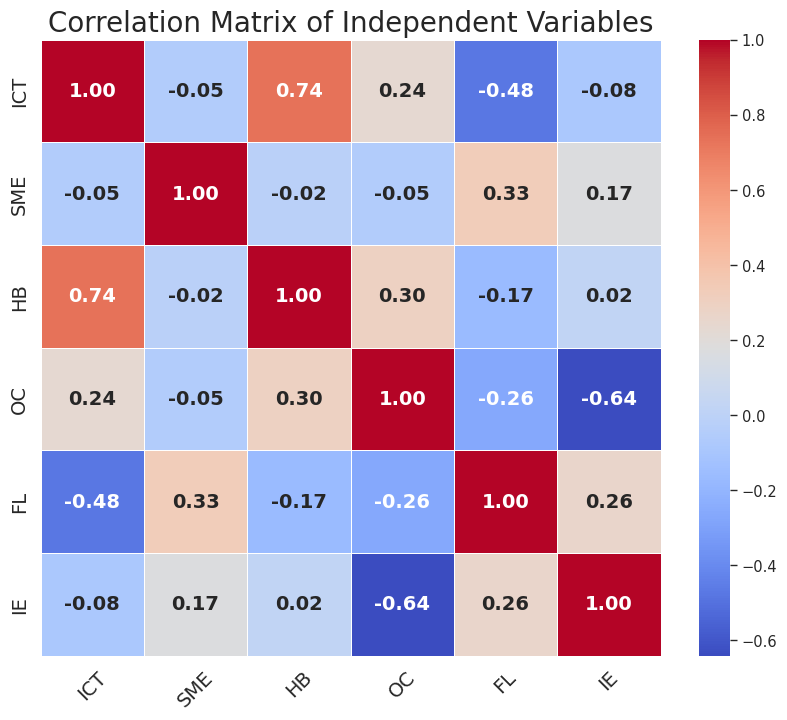

Variance Inflation Factor (VIF):
   Variable       VIF
0      ICT  3.223299
2       HB  2.866413
3       OC  2.128379
5       IE  1.975174
4       FL  1.757846
1      SME  1.182503


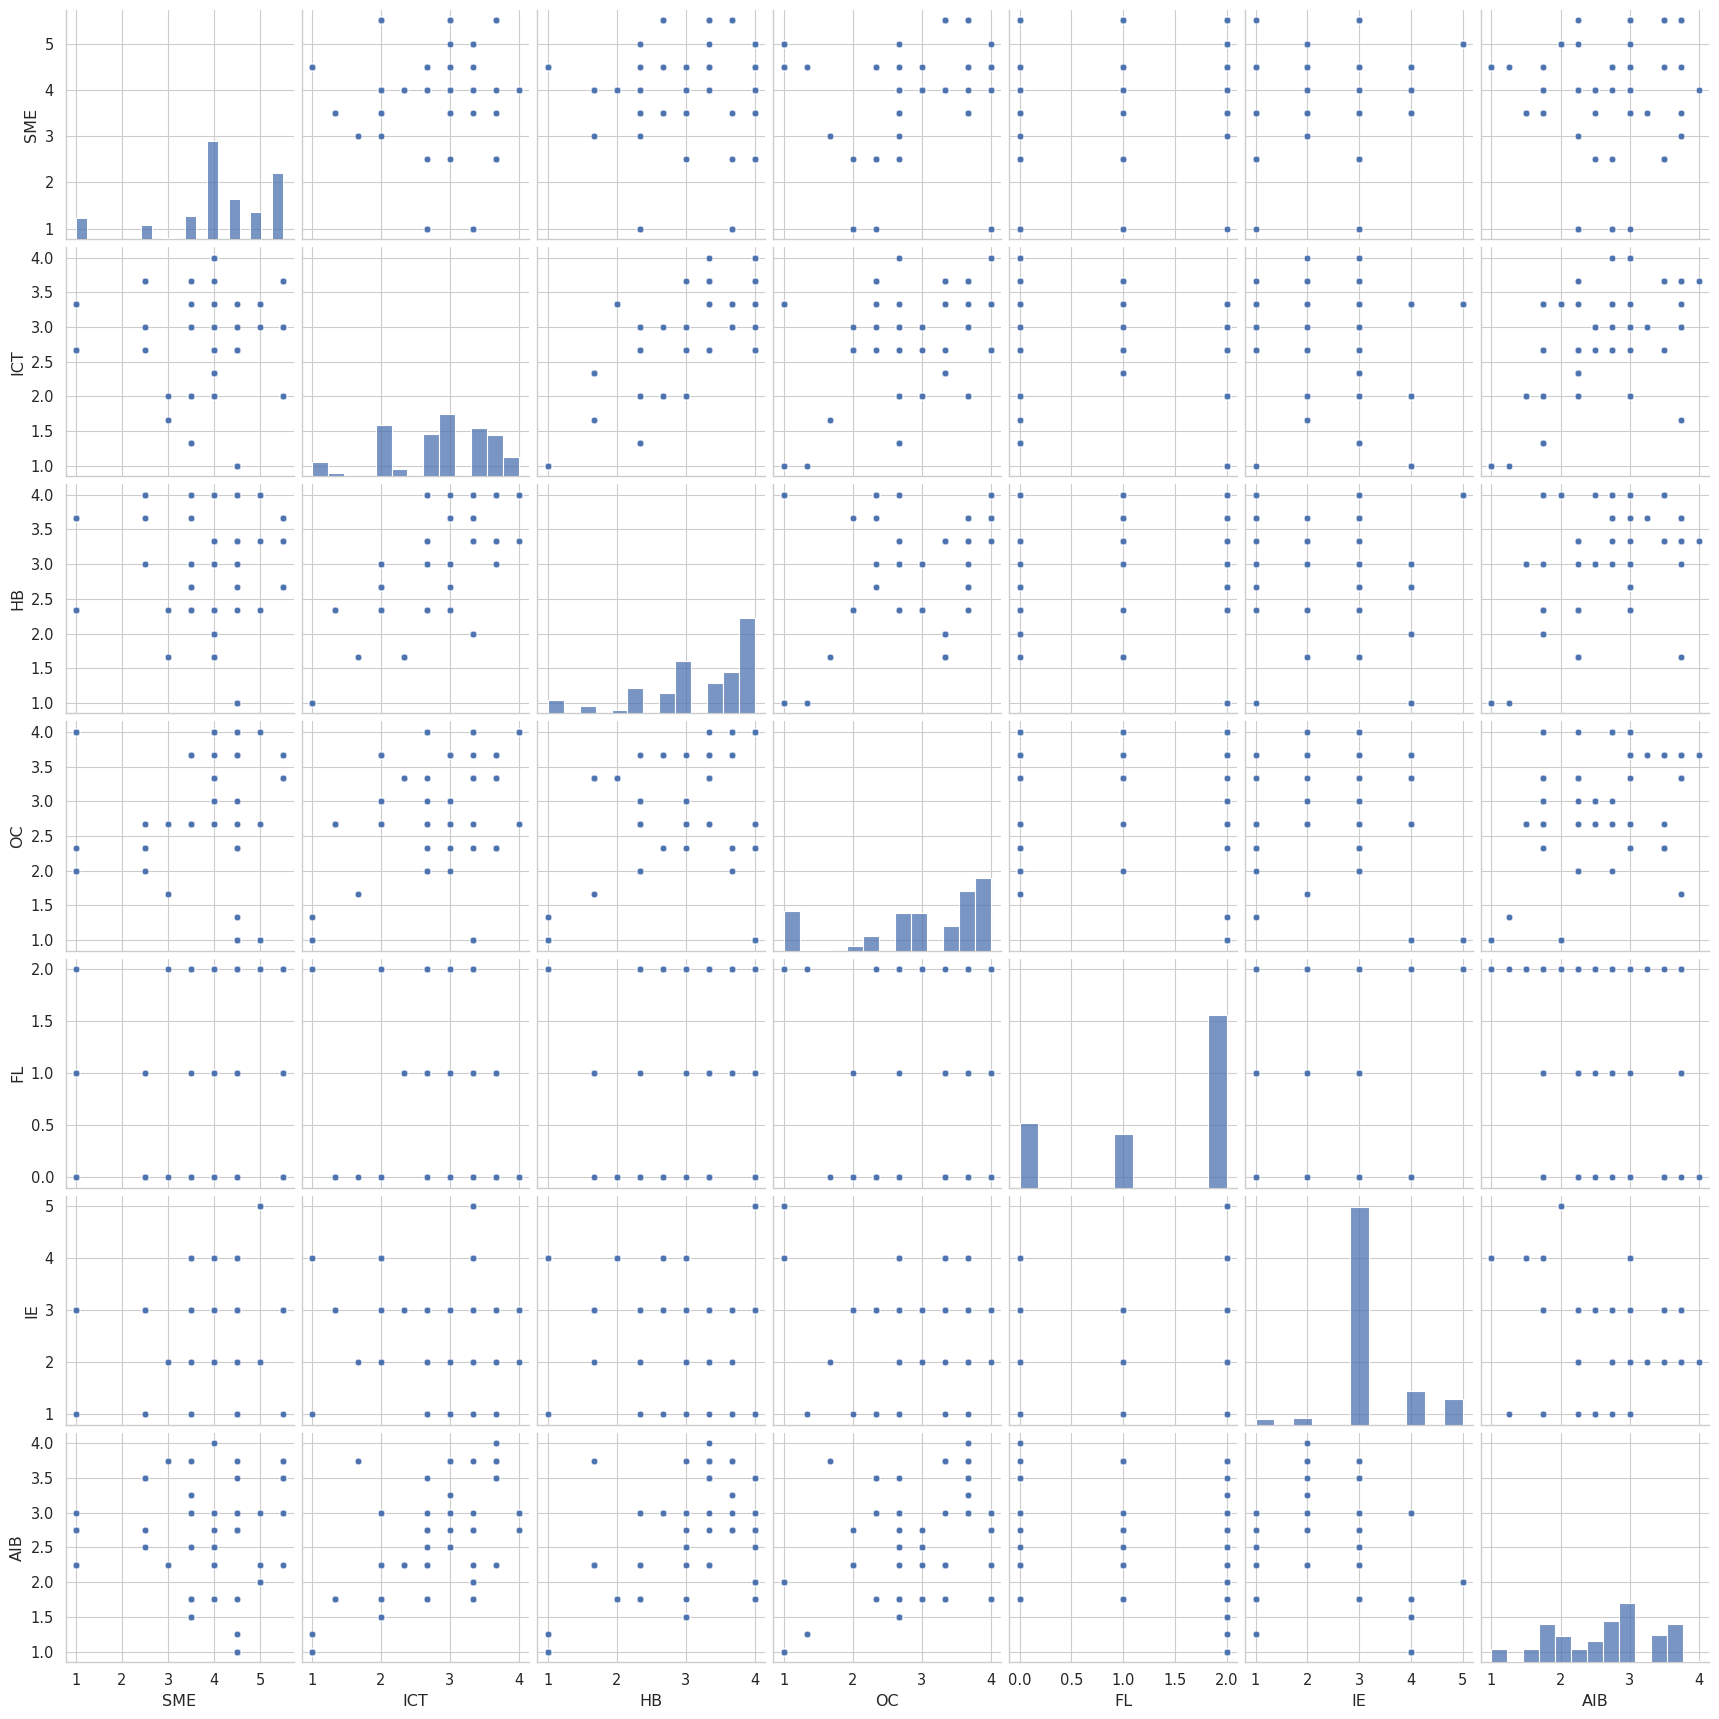

In [41]:
# ==========================================
# GROUP 6: Defining Variables & Statistical Checks
# ==========================================
# Define X and Y
y = df['AIB']
x = df[['ICT', 'SME', 'HB', 'OC', 'FL', 'IE']]

# Generate Correlation Heatmap
correlation_matrix = x.corr()
plt.figure(figsize=(10, 8))

# 1. 'annot_kws' controls the size of the numbers inside the squares
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5,
            annot_kws={"size": 14, "weight": "bold"}) # Increased number size

# 2. Use xticks and yticks to control the variable name sizes
plt.xticks(fontsize=14, rotation=45) # Size of x-axis labels
plt.yticks(fontsize=14)              # Size of y-axis labels

plt.title('Correlation Matrix of Independent Variables', fontsize=20)

# Save and show
plt.savefig('correlation_heatmap_300.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

# Calculate Variance Inflation Factor (VIF)
X_with_const = sm.add_constant(x)
vif_data = pd.DataFrame()
vif_data['Variable'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.to_numpy(), i) for i in range(X_with_const.shape[1])]
vif_data = vif_data[vif_data['Variable'] != 'const'].reset_index(drop=True)
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print("Variance Inflation Factor (VIF):\n", vif_data)

# Generate Pairplot
sns.pairplot(df)
plt.show()

In [42]:
# ==========================================
# GROUP 7: Model Training, Statistical Checks & Evaluation
# ==========================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# --- 1. TRAIN/TEST SPLIT & MODEL TRAINING ---
# Standard 80% Training, 20% Testing split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

print(f"Total dataset size: {x.shape[0]} rows")
print(f"Training data size: {x_train.shape[0]} rows")
print(f"Testing data size:  {x_test.shape[0]} rows\n")

# Initialize and train the MLR model on the TRAINING data only
ml_model = LinearRegression()
ml_model.fit(x_train, y_train)

# --- 2. FORMATTED MODEL RESULTS (WEIGHTS) ---
print("==================================================")
print("             SKLEARN MODEL COEFFICIENTS           ")
print("==================================================")

# Create a clean DataFrame to display the features and their impact
coefficients_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient (Weight)': ml_model.coef_
})

# Sort by the absolute value to see which feature has the biggest impact
coefficients_df['Abs_Weight'] = coefficients_df['Coefficient (Weight)'].abs()
coefficients_df = coefficients_df.sort_values(by='Abs_Weight', ascending=False).drop(columns=['Abs_Weight'])

print(coefficients_df.to_string(index=False))
print("-" * 50)
print(f"Base Intercept: {ml_model.intercept_:.4f}")
print("==================================================")

# --- 3. STATISTICAL SIGNIFICANCE (P-VALUES) ---
# statsmodels requires us to explicitly add the intercept column
x_train_sm = sm.add_constant(x_train)

# Fit the Ordinary Least Squares (OLS) model
stat_model = sm.OLS(y_train, x_train_sm).fit()

# Print the academic summary table
print(stat_model.summary())

# --- 4. SKLEARN MODEL EVALUATION (ON TEST DATA) ---
# Make predictions on the 20% test set
y_pred = ml_model.predict(x_test)

# Calculate a naive baseline prediction (just guessing the mean of the training data)
baseline_pred = np.full_like(y_test, y_train.mean())

# Calculate metrics for our MLR model
mlr_mse = metrics.mean_squared_error(y_test, y_pred)
mlr_mae = metrics.mean_absolute_error(y_test, y_pred)
mlr_r2 = metrics.r2_score(y_test, y_pred)

# Calculate metrics for the Baseline
base_mse = metrics.mean_squared_error(y_test, baseline_pred)

print("==================================================")
print("             MODEL EVALUATION METRICS             ")
print("==================================================")
print(f"Model R-Squared (R²):     {mlr_r2:.4f}")
print(f"Model Mean Abs Error:     {mlr_mae:.4f}")
print(f"Model Mean Squared Error: {mlr_mse:.4f}")
print("-" * 50)
print(f"Baseline Mean Sq Error:   {base_mse:.4f}")
print(f"Improvement over baseline: {((base_mse - mlr_mse) / base_mse) * 100:.2f}%")
print("==================================================")

Total dataset size: 546 rows
Training data size: 436 rows
Testing data size:  110 rows

             SKLEARN MODEL COEFFICIENTS           
Feature  Coefficient (Weight)
    ICT              0.595275
     IE             -0.452952
    SME              0.192674
     OC              0.086852
     HB              0.028495
     FL              0.027376
--------------------------------------------------
Base Intercept: 1.1965
                            OLS Regression Results                            
Dep. Variable:                    AIB   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     129.8
Date:                Tue, 05 May 2026   Prob (F-statistic):           3.56e-93
Time:                        14:33:20   Log-Likelihood:                -276.74
No. Observations:                 436   AIC:                             567.5
Df Residuals:           

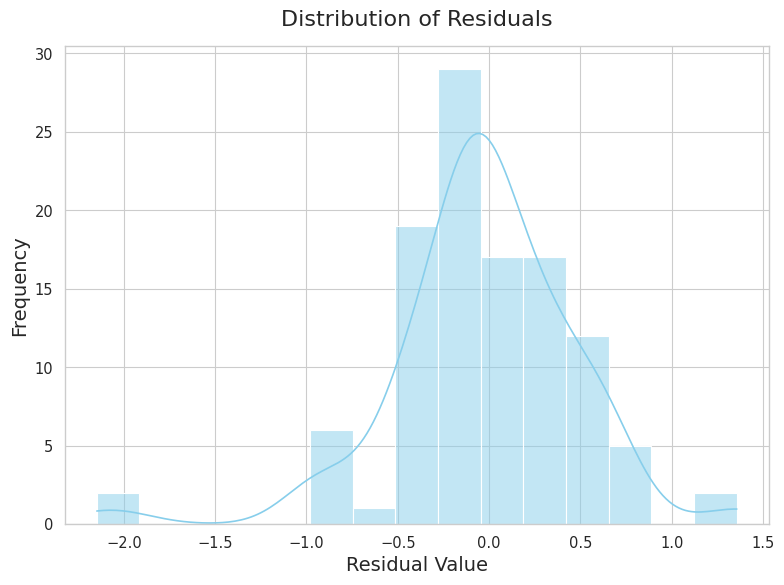

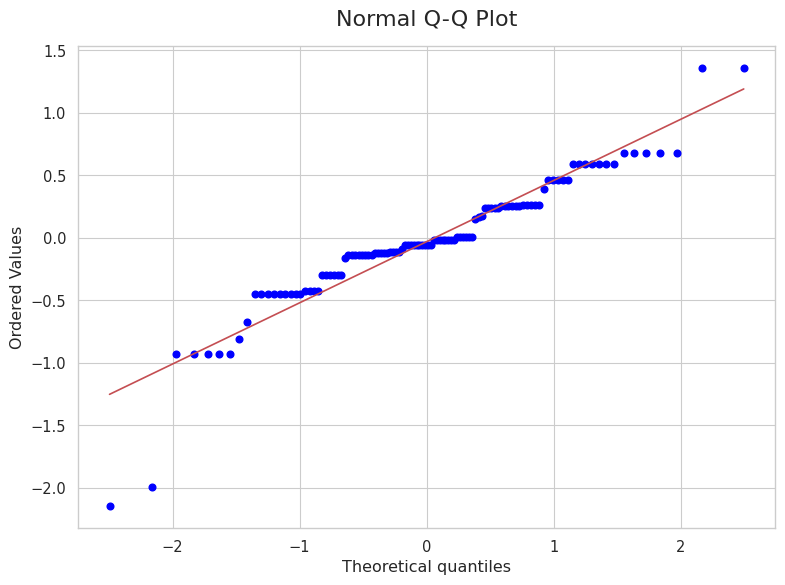

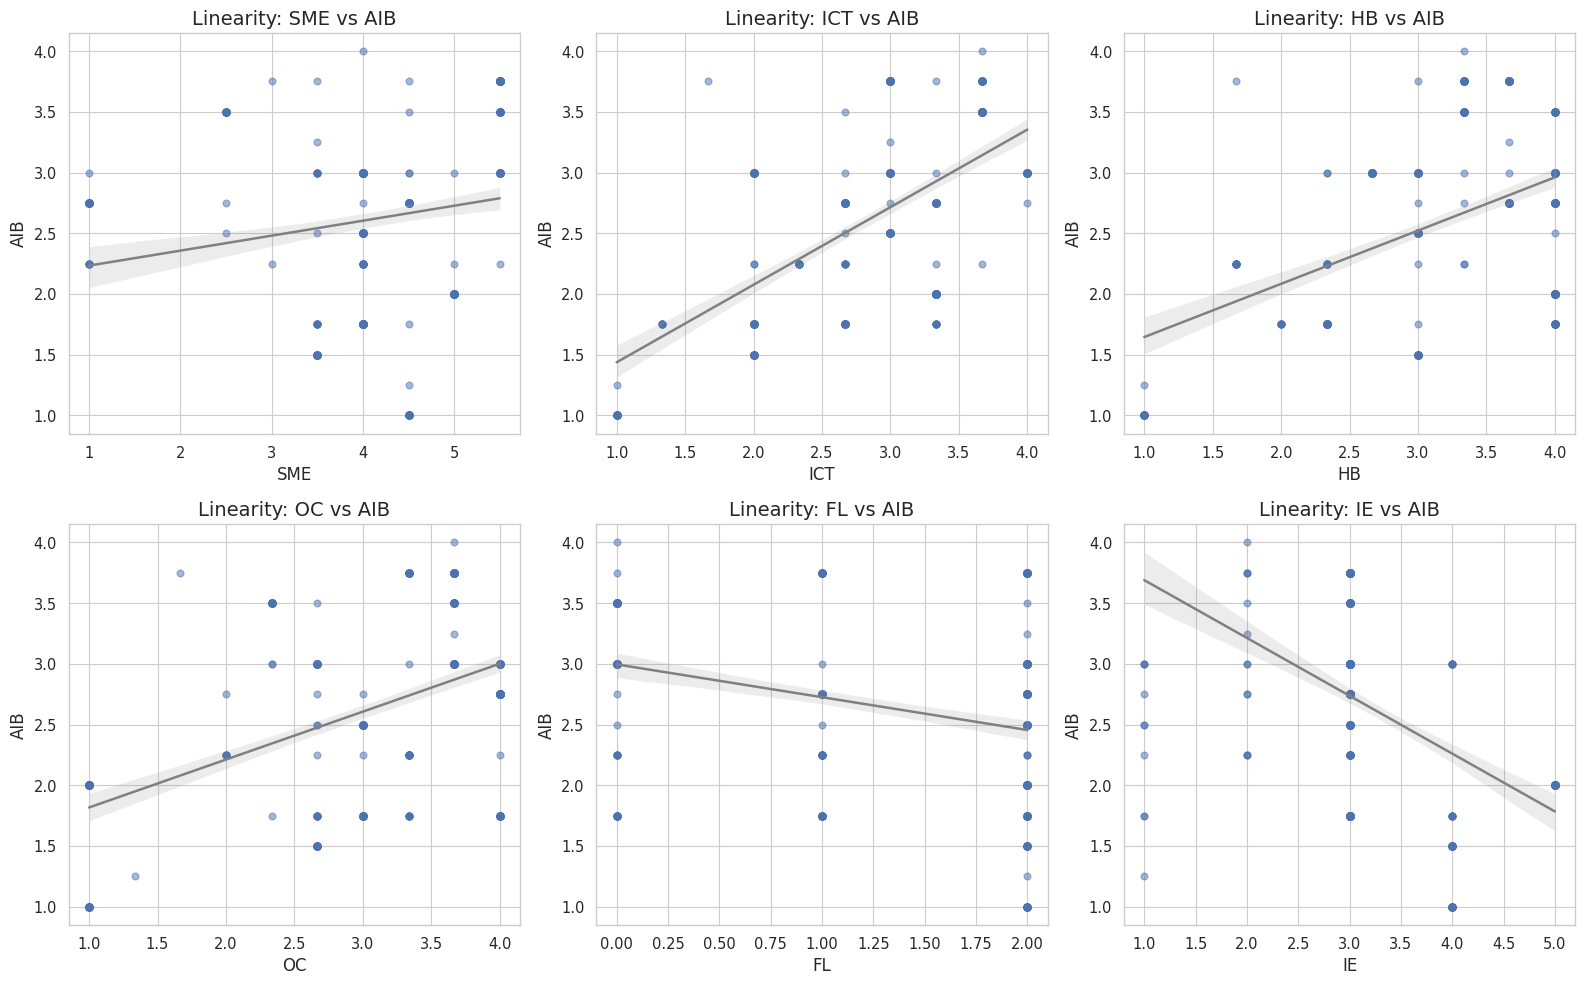

/tmp/ipykernel_10298/2344721060.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['Proposed MLR Model', 'Naive Baseline (Mean)'],


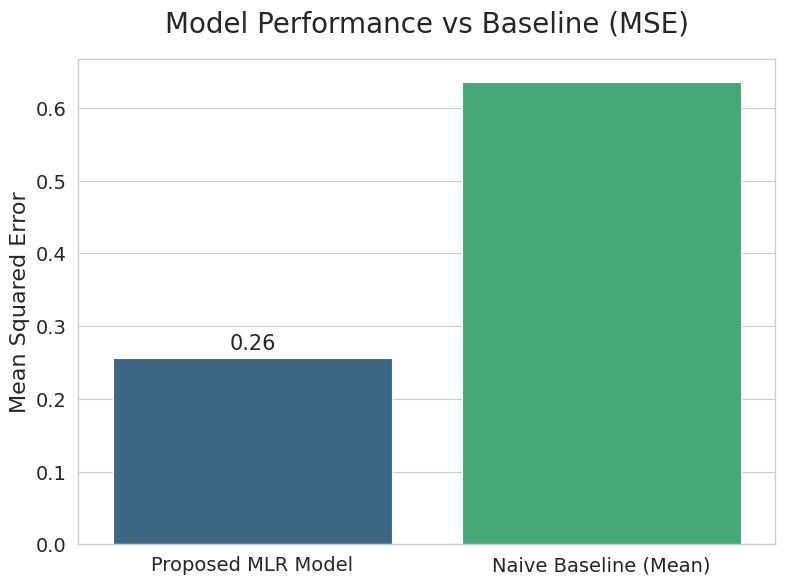

In [43]:
# ==========================================
# GROUP 8: HIGH-RESOLUTION GRAPH GENERATION & DIAGNOSTICS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set global visual style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Calculate residuals from the test set predictions
residuals = y_test - y_pred

# --- GRAPH 1: Residual Normality Check (Distribution) ---
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color="skyblue", bins=15)
plt.title("Distribution of Residuals", fontsize=16, pad=15)
plt.xlabel("Residual Value", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.tight_layout()
plt.savefig("residual_distribution_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# --- GRAPH 2: Residual Normality Check (Q-Q Plot) ---
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Normal Q-Q Plot", fontsize=16, pad=15)
ax.get_lines()[0].set_markerfacecolor('blue')
ax.get_lines()[0].set_markeredgecolor('blue')
plt.tight_layout()
plt.savefig("qq_plot_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# --- GRAPH 3: Linearity Check (Feature vs Target) ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
features = ['SME', 'ICT', 'HB', 'OC', 'FL', 'IE']

for i, feature in enumerate(features):
    # Using lowercase 'x' as defined in Group 6
    sns.regplot(x=x[feature], y=y, ax=axes[i], scatter_kws={'alpha':0.5}, line_kws={'color':'gray'})
    axes[i].set_title(f"Linearity: {feature} vs AIB", fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel("AIB", fontsize=12)

plt.tight_layout()
plt.savefig("linearity_check_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# --- GRAPH 4: Performance Comparison ---
plt.figure(figsize=(8, 6))

# Assign to an 'ax' variable to easily manipulate labels
ax = sns.barplot(x=['Proposed MLR Model', 'Naive Baseline (Mean)'],
                y=[mlr_mse, base_mse],
                palette="viridis")

# 1. Increase Title, X-label, and Y-label sizes
plt.title("Model Performance vs Baseline (MSE)", fontsize=20, pad=20)
plt.ylabel("Mean Squared Error", fontsize=16)

# 2. Increase the size of the axis tick labels (the names and scale)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 3. Add and scale the numbers on top of the bars
# 'padding' moves the text slightly above the bar
ax.bar_label(ax.containers[0], fontsize=15, padding=3, fmt='%.2f')

plt.tight_layout()
plt.savefig("performance_comparison_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

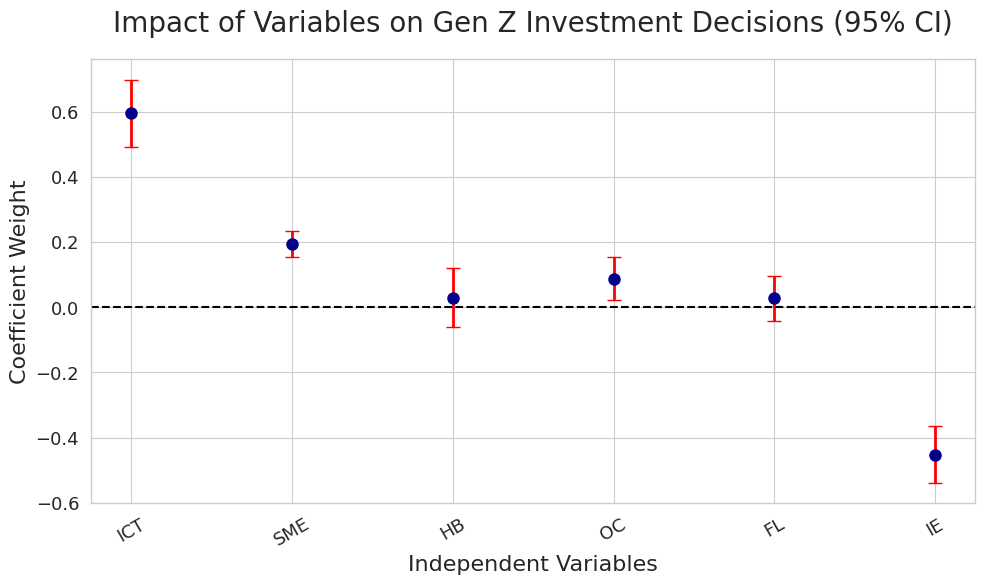

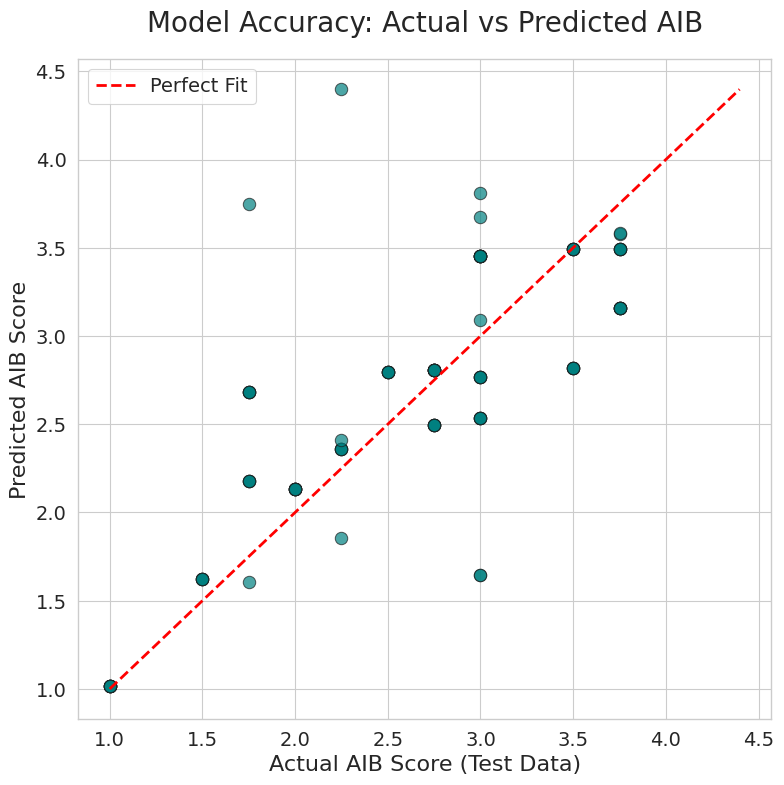

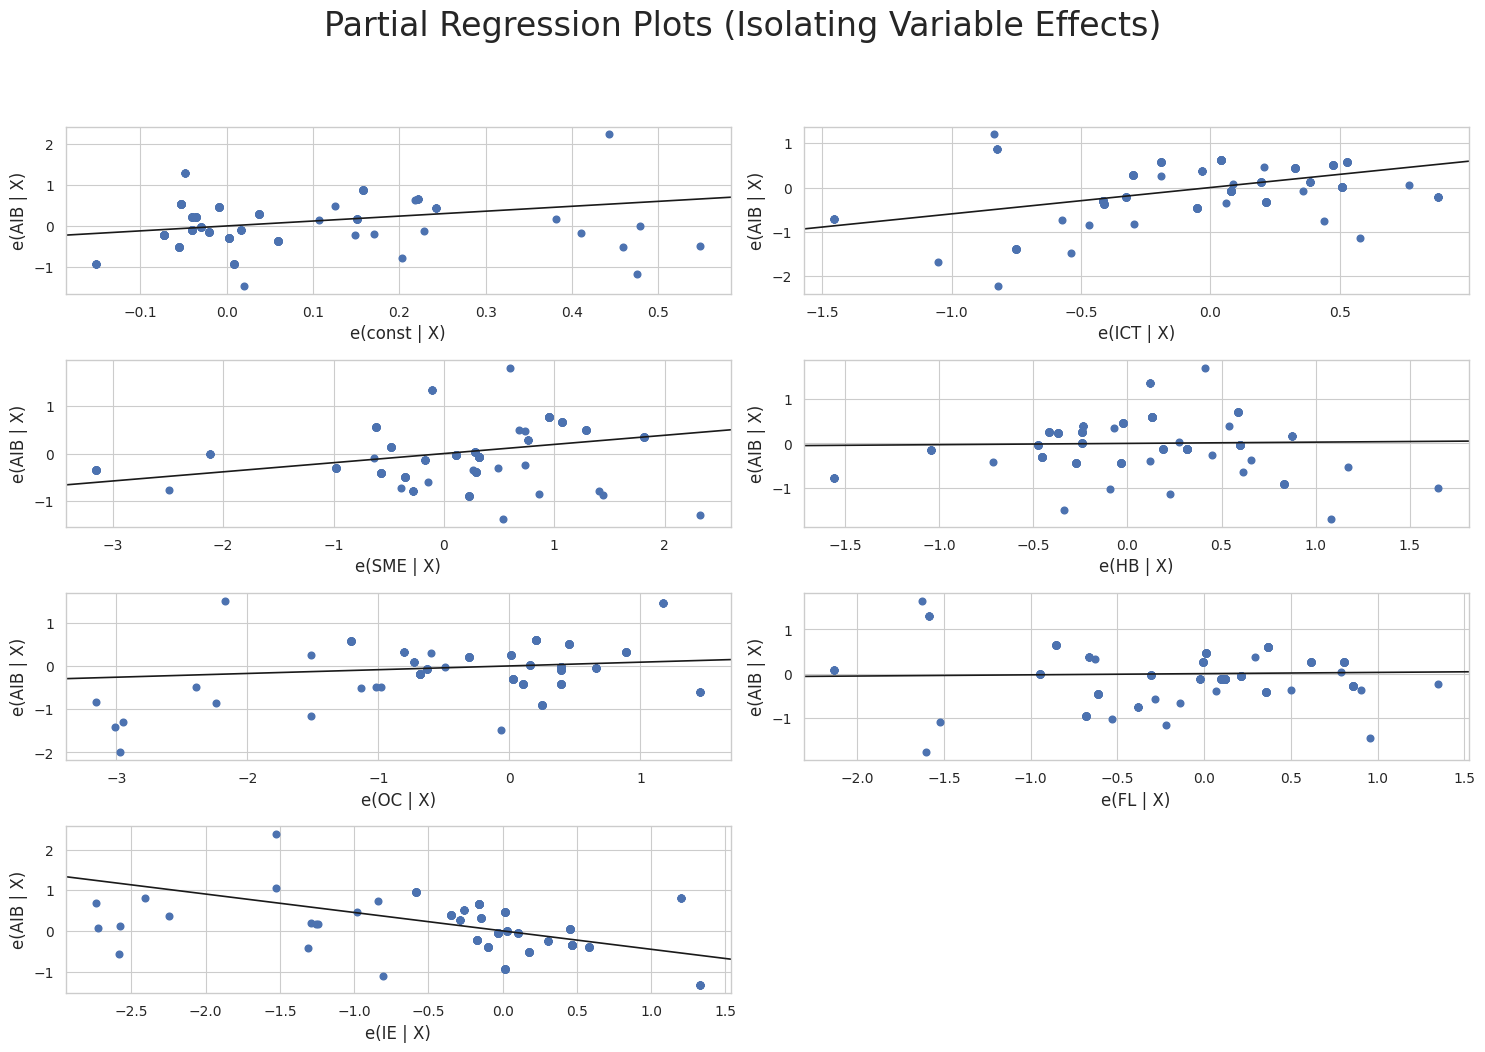

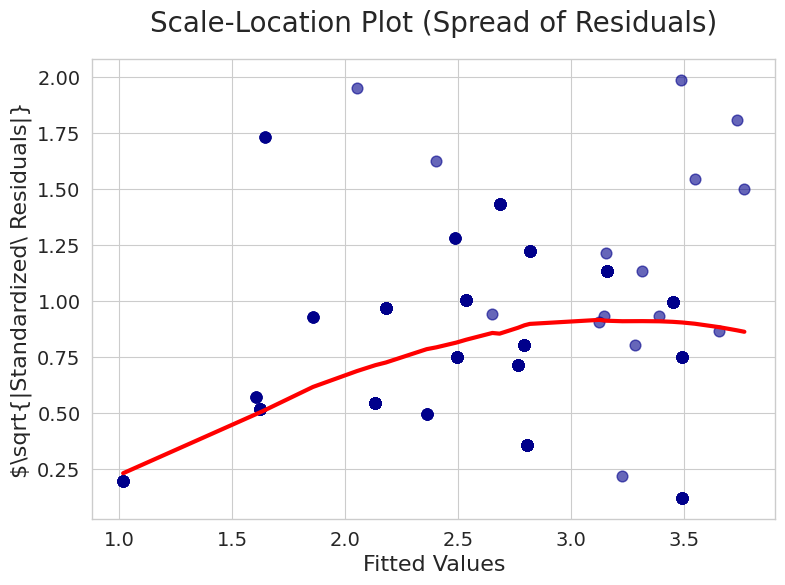

In [44]:
# ==========================================
# GROUP 9: ADVANCED THESIS GRAPHS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm

# Set global visual style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Ensure you have your fitted statsmodel ('stat_model') and predictions ('y_pred') from Group 7
# X_train_sm and y_train are also required.

# --------------------------------------------------
# GRAPH 1: Coefficient Forest Plot (Impact of Variables)
# --------------------------------------------------
plt.figure(figsize=(10, 6))

# Calculate confidence intervals and errors from the stat_model
conf_int = stat_model.conf_int(alpha=0.05) # 95% confidence interval
conf_int.columns = ['Lower CI', 'Upper CI']
coefficients = stat_model.params.drop('const') # Get coefficients, dropping the intercept

# Combine coefficients and confidence intervals
plot_data = pd.DataFrame({
    'Coefficient': coefficients,
    'Lower CI': conf_int['Lower CI'].drop('const'),
    'Upper CI': conf_int['Upper CI'].drop('const')
})
plot_data['errors'] = plot_data['Coefficient'] - plot_data['Lower CI']

# Plotting the forest plot
plt.errorbar(x=plot_data.index, y=plot_data['Coefficient'], yerr=plot_data['errors'],
             fmt='o', color='darkblue', ecolor='red', elinewidth=2, capsize=5, markersize=8)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5) # Zero effect line

# 1. Title and Axis Label sizes
plt.title("Impact of Variables on Gen Z Investment Decisions (95% CI)", fontsize=20, pad=20)
plt.ylabel("Coefficient Weight", fontsize=16)
plt.xlabel("Independent Variables", fontsize=16)

# 2. Axis Ticks (Labels and Scale)
plt.xticks(fontsize=13, rotation=30)
plt.yticks(fontsize=13)

# Note: The loop for adding numeric labels has been removed to clean up the visual.

plt.tight_layout()
plt.savefig("coefficient_forest_plot_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()


# --------------------------------------------------
# GRAPH 2: Actual vs. Predicted Plot
# --------------------------------------------------
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal', edgecolor='k', s=80) # Increased point size (s)

# Draw the ideal 45-degree line (Perfect Prediction)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

# 1. Increase Title and Axis Label sizes
plt.title("Model Accuracy: Actual vs Predicted AIB", fontsize=20, pad=20)
plt.xlabel("Actual AIB Score (Test Data)", fontsize=16)
plt.ylabel("Predicted AIB Score", fontsize=16)

# 2. Increase the size of the tick numbers on both axes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# 3. Increase the Legend font size
plt.legend(fontsize=14, loc='upper left')

plt.tight_layout()
plt.savefig("actual_vs_predicted_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()


# --- GRAPH 3: Partial Regression Plots ---
fig = plt.figure(figsize=(15, 10))
sm.graphics.plot_partregress_grid(stat_model, fig=fig)

# 1. Update the overall Title
plt.suptitle("Partial Regression Plots (Isolating Variable Effects)", fontsize=24, y=1.05)

# 2. Loop through every subplot in the grid to update axis text and numbers
for ax in fig.axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=12) # X-axis title size
    ax.set_ylabel(ax.get_ylabel(), fontsize=12) # Y-axis title size
    ax.tick_params(axis='both', labelsize=10)   # Size of the numbers on axes

plt.tight_layout()
plt.savefig("partial_regression_plots_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()


# --- GRAPH 4: Scale-Location Plot ---
std_residuals = stat_model.get_influence().resid_studentized_internal
sqrt_std_residuals = np.sqrt(np.abs(std_residuals))

plt.figure(figsize=(8, 6))
sns.regplot(x=stat_model.fittedvalues, y=sqrt_std_residuals,
            scatter_kws={'alpha':0.6, 'color':'darkblue', 's':60},
            line_kws={'color':'red', 'lw':3}, lowess=True)

# 1. Increase Title and Label sizes
plt.title("Scale-Location Plot (Spread of Residuals)", fontsize=20, pad=20)
plt.xlabel("Fitted Values", fontsize=16)

# Using LaTeX for the complex math label
plt.ylabel(r"$\sqrt{|Standardized\ Residuals|}", fontsize=16)

# 2. Increase the size of the tick numbers
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("scale_location_plot_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

Graphs for google site

/tmp/ipykernel_10298/2015774347.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='IE_Labels', order=order_list, palette="Blues_d")


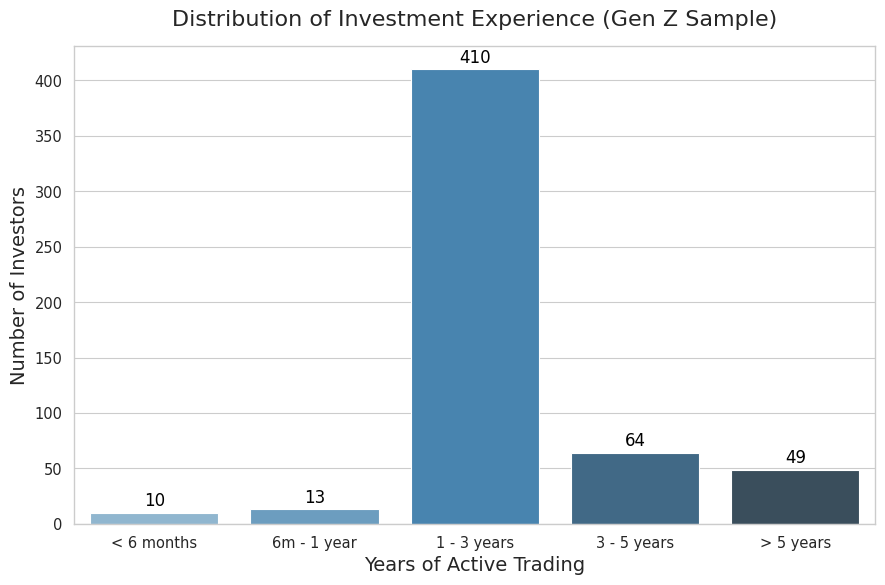

/tmp/ipykernel_10298/2015774347.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='FL', palette="magma")


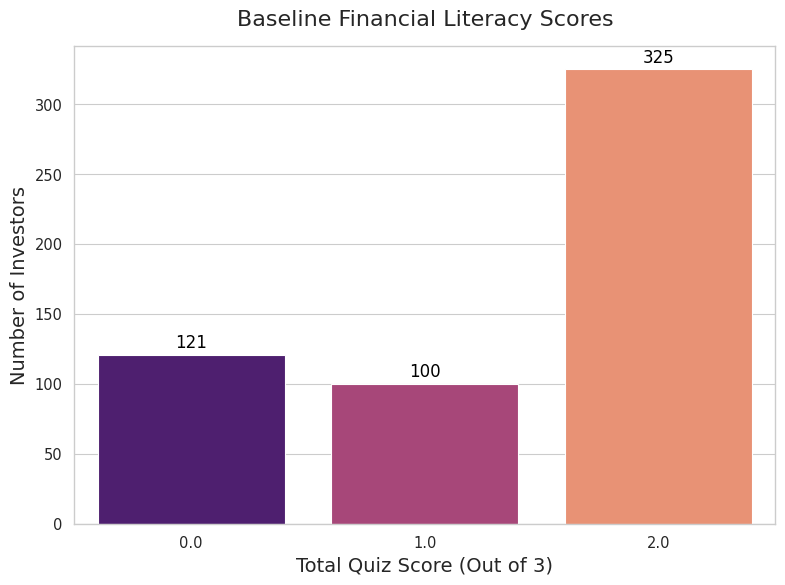

In [45]:
# ==========================================
# GROUP 10: DESCRIPTIVE SURVEY GRAPHS (PRE-MLR)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set global visual style for presentation-ready graphs
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Ensure 'df' is loaded from the preprocessed data (Group 5)
# If running out of order, ensure df contains 'IE' and 'FL' columns.

# --------------------------------------------------
# GRAPH 1: Investment Experience (IE) Bar Chart
# --------------------------------------------------
# Map the numeric IE values back to readable labels for the presentation
ie_labels = {
    1.0: '< 6 months',
    2.0: '6m - 1 year',
    3.0: '1 - 3 years',
    4.0: '3 - 5 years',
    5.0: '> 5 years'
}

# Create a temporary column for plotting
df['IE_Labels'] = df['IE'].map(ie_labels)
# Ensure the order is chronologically correct on the x-axis
order_list = ['< 6 months', '6m - 1 year', '1 - 3 years', '3 - 5 years', '> 5 years']

plt.figure(figsize=(9, 6))
ax = sns.countplot(data=df, x='IE_Labels', order=order_list, palette="Blues_d")
plt.title("Distribution of Investment Experience (Gen Z Sample)", fontsize=16, pad=15)
plt.xlabel("Years of Active Trading", fontsize=14)
plt.ylabel("Number of Investors", fontsize=14)

# Add data labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig("investment_experience_bar_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# GRAPH 2: Financial Literacy (FL) Score Distribution
# --------------------------------------------------
plt.figure(figsize=(8, 6))
# Since FL is a discrete score out of 3, a countplot works perfectly
ax2 = sns.countplot(data=df, x='FL', palette="magma")
plt.title("Baseline Financial Literacy Scores", fontsize=16, pad=15)
plt.xlabel("Total Quiz Score (Out of 3)", fontsize=14)
plt.ylabel("Number of Investors", fontsize=14)

# Add data labels on top of the bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                 textcoords='offset points')

plt.tight_layout()
plt.savefig("financial_literacy_dist_300.jpeg", dpi=300, bbox_inches='tight')
plt.show()

# Clean up the temporary column
df.drop(columns=['IE_Labels'], inplace=True)

In [46]:
# ==========================================
# GROUP 11: EXPORT & DOWNLOAD ALL ASSETS
# ==========================================
import os
import zipfile

# 1. Save the final processed dataset
# Saving as CSV is preferred for GitHub/Code submissions, but you can change .csv to .xlsx if needed
final_data_filename = "Final_Processed_dataset_BRDM.csv"
df.to_csv(final_data_filename, index=False)
print(f"Saved processed dataset to {final_data_filename}")

# 2. Zip all generated assets together for easy submission
zip_filename = "Quantifying_Finfluencer_Influence_Assets.zip"

# Find all the high-resolution JPEG graphs we saved in the current directory
jpeg_files = [f for f in os.listdir('.') if f.endswith('.jpeg')]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Add the cleaned dataset
    zipf.write(final_data_filename)
    # Add all the graphs
    for file in jpeg_files:
        zipf.write(file)

print(f"Packaged {len(jpeg_files)} graphs and the final dataset into {zip_filename}.")

# 3. Trigger the download to your local machine (Google Colab specific)
try:
    from google.colab import files
    files.download(zip_filename)
    print("Download triggered successfully! You can now use these files for your Google Site and Submission.")
except ImportError:
    print("Note: files.download() only works in Google Colab. If you are running this locally, your zip file is already saved in your current folder.")

Saved processed dataset to Final_Processed_dataset_BRDM.csv
Packaged 11 graphs and the final dataset into Quantifying_Finfluencer_Influence_Assets.zip.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered successfully! You can now use these files for your Google Site and Submission.
